# IPL Data Analytics Project

Analyzed 260,000+ IPL deliveries using Pandas and Matplotlib to derive player performance, team insights, strike rate analysis, economy analysis, and scoring trends.

In [44]:
print("Notebook is working")

Notebook is working


In [45]:
import pandas as pd

df = pd.read_csv("deliveries.csv")

df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [46]:
df.shape

(260920, 17)

In [47]:
df.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [48]:
df.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [49]:
df['batting_team'].unique()

array(['Kolkata Knight Riders', 'Royal Challengers Bangalore',
       'Chennai Super Kings', 'Kings XI Punjab', 'Rajasthan Royals',
       'Delhi Daredevils', 'Mumbai Indians', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [50]:
df['batting_team'].nunique()

19

In [51]:
df['batting_team'].value_counts()

batting_team
Mumbai Indians                 31437
Kolkata Knight Riders          29514
Chennai Super Kings            28651
Royal Challengers Bangalore    28205
Rajasthan Royals               26242
Kings XI Punjab                22646
Sunrisers Hyderabad            21843
Delhi Daredevils               18786
Delhi Capitals                 10946
Deccan Chargers                 9034
Punjab Kings                    6833
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiant          1900
Royal Challengers Bengaluru     1818
Kochi Tuskers Kerala            1582
Rising Pune Supergiants         1580
Name: count, dtype: int64

In [52]:
df['batting_team'].replace({
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Punjab Kings': 'Kings XI Punjab',
    'Delhi Capitals': 'Delhi Daredevils',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}, inplace=True)

/var/folders/wl/5y1xfnpn5t11q_qwnb6jcm4c0000gn/T/ipykernel_1079/674760098.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['batting_team'].replace({


In [53]:
df['batting_team'].nunique()

15

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [55]:
df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

<Axes: xlabel='batter'>

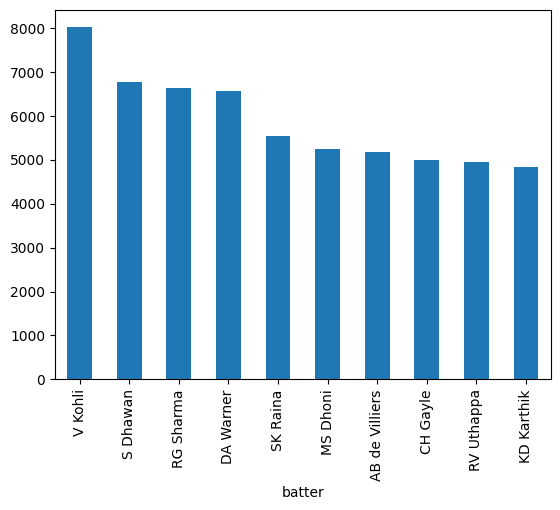

In [56]:
df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

Top Run Scorers

In [57]:
df.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: is_wicket, dtype: int64

<Axes: xlabel='bowler'>

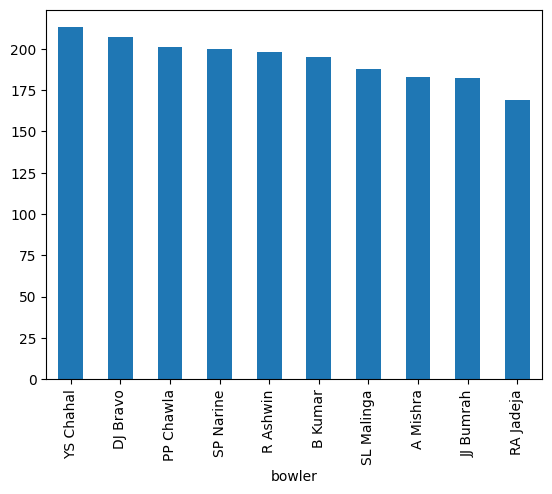

In [58]:
df.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

Top Wicket Takers

In [59]:
top_sixes = (
    df[df['batsman_runs'] == 6]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_sixes

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
dtype: int64

<Axes: xlabel='batter'>

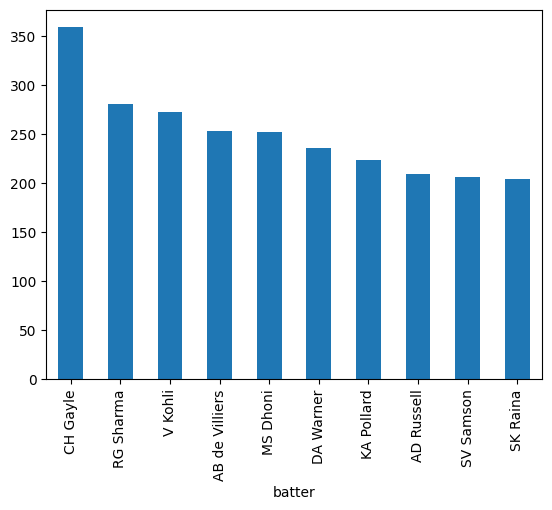

In [60]:
top_sixes.plot(kind='bar')

Top 10 Six Hitters in IPL History

In [61]:
team_runs = (
    df.groupby('batting_team')['total_runs']
      .sum()
      .sort_values(ascending=False)
)

team_runs

batting_team
Mumbai Indians                 42176
Royal Challengers Bangalore    40622
Kings XI Punjab                39600
Kolkata Knight Riders          39331
Delhi Daredevils               39196
Chennai Super Kings            38629
Rajasthan Royals               34747
Sunrisers Hyderabad            29071
Deccan Chargers                11463
Gujarat Titans                  7757
Lucknow Super Giants            7510
Pune Warriors                   6358
Gujarat Lions                   4862
Rising Pune Supergiant          4533
Kochi Tuskers Kerala            1901
Name: total_runs, dtype: int64

<Axes: xlabel='batting_team'>

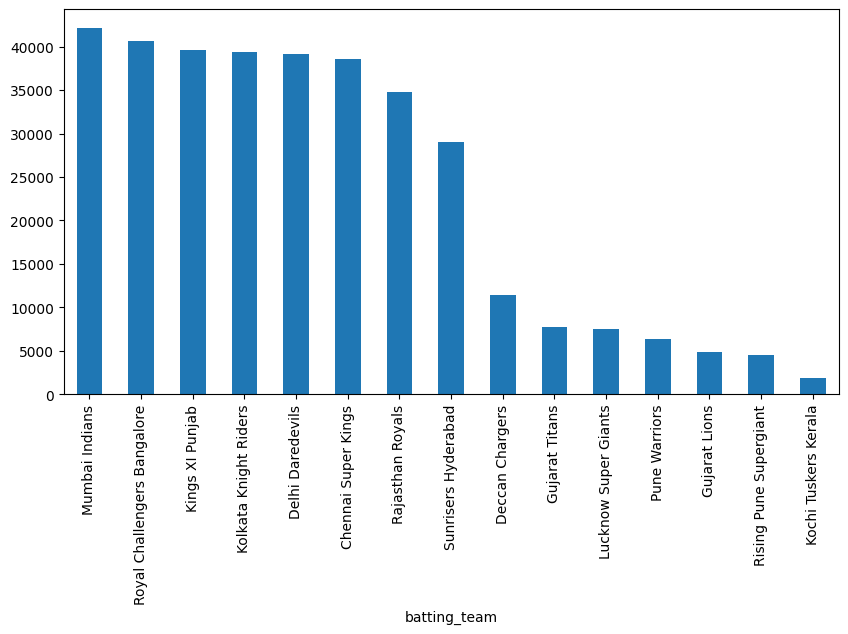

In [62]:
team_runs.plot(kind='bar', figsize=(10,5))

Team-wise Total Runs in IPL History

In [63]:
strike_rate = (
    df.groupby('batter')
      .agg(
          runs=('batsman_runs', 'sum'),
          balls=('batter', 'count')
      )
)

strike_rate['SR'] = (strike_rate['runs'] / strike_rate['balls']) * 100

strike_rate = strike_rate[strike_rate['balls'] >= 500]

strike_rate.sort_values('SR', ascending=False).head(10)

,runs,balls,SR
batter,,,
AD Russell,2488,1515,164.224422
H Klaasen,993,613,161.990212
SP Narine,1534,984,155.894309
N Pooran,1769,1143,154.768154
LS Livingstone,939,609,154.187192
GJ Maxwell,2772,1842,150.488599
RM Patidar,799,534,149.625468
Abhishek Sharma,1377,925,148.864865
V Sehwag,2728,1833,148.827059


<Axes: xlabel='batter'>

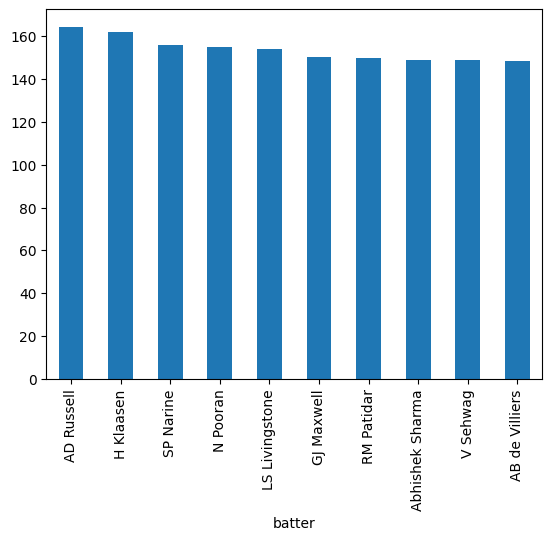

In [64]:
strike_rate.sort_values('SR', ascending=False).head(10)['SR'].plot(kind='bar')

Strike Rate Analysis

In [65]:
economy = (
    df.groupby('bowler')
      .agg(
          runs_given=('total_runs', 'sum'),
          balls=('bowler', 'count')
      )
)

economy = economy[economy['balls'] >= 500]

economy['overs'] = economy['balls'] / 6
economy['economy'] = economy['runs_given'] / economy['overs']

economy.sort_values('economy').head(10)

,runs_given,balls,overs,economy
bowler,,,,
A Kumble,1089,983,163.833333,6.646999
M Muralitharan,1765,1581,263.500000,6.698292
SP Narine,4672,4146,691.000000,6.761216
DW Steyn,2583,2282,380.333333,6.791411
DL Vettori,894,785,130.833333,6.833121
Rashid Khan,3340,2901,483.500000,6.907963
J Botha,818,709,118.166667,6.922426
R Ashwin,5435,4679,779.833333,6.969438
MM Ali,900,770,128.333333,7.012987


<Axes: xlabel='bowler'>

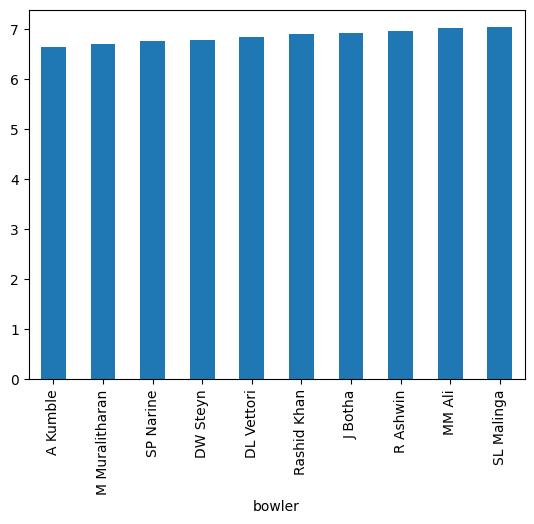

In [66]:
economy.sort_values('economy').head(10)['economy'].plot(kind='bar')

Economy Rate Analysis

In [67]:
top_bowlers_stats = (
    df.groupby('bowler')
      .agg(
          wickets=('is_wicket', 'sum'),
          runs_given=('total_runs', 'sum'),
          balls=('bowler', 'count')
      )
)

top_bowlers_stats.head()

,wickets,runs_given,balls
bowler,,,
A Ashish Reddy,19,400,270
A Badoni,2,37,25
A Chandila,11,245,234
A Choudhary,5,144,108
A Dananjaya,0,47,25


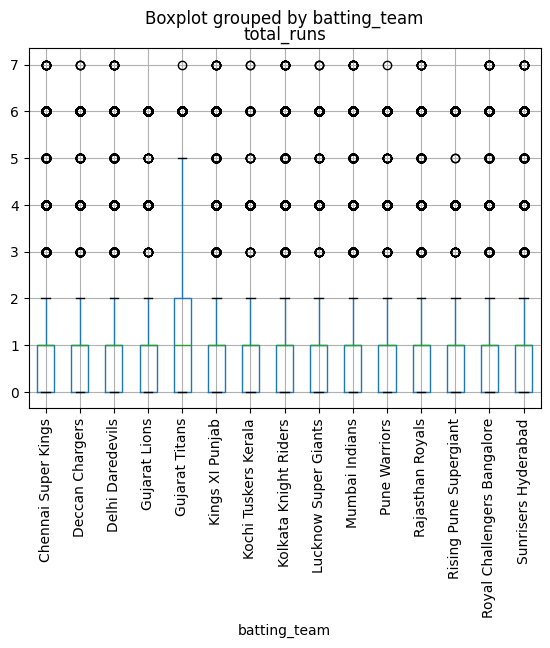

In [70]:
import matplotlib.pyplot as plt

df.boxplot(column='total_runs', by='batting_team', rot=90)
plt.show()

<Axes: xlabel='runs', ylabel='strike_rate'>

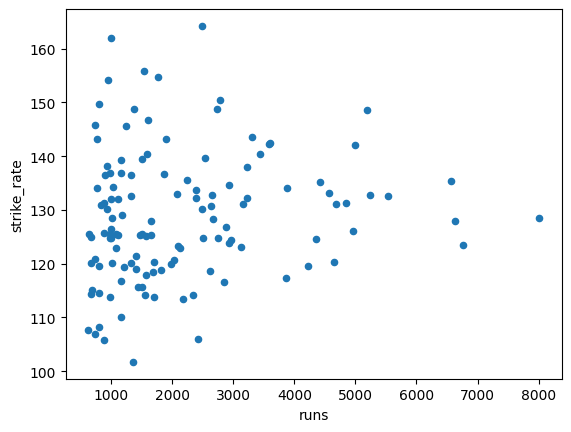

In [71]:
batter_stats = df.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batter', 'count')
)

batter_stats = batter_stats[batter_stats['balls'] >= 500]

batter_stats['strike_rate'] = (
    batter_stats['runs'] / batter_stats['balls']
) * 100

batter_stats.plot(
    kind='scatter',
    x='runs',
    y='strike_rate'
)

Batter Runs vs Strike Rate

In [72]:
partnerships = (
    df.groupby(['batter', 'non_striker'])['total_runs']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

partnerships

batter          non_striker   
AB de Villiers  V Kohli           1623
CH Gayle        V Kohli           1617
V Kohli         AB de Villiers    1511
DA Warner       S Dhawan          1420
V Kohli         CH Gayle          1185
RV Uthappa      G Gambhir         1077
V Kohli         F du Plessis      1050
Ishan Kishan    RG Sharma          992
F du Plessis    V Kohli            982
S Dhawan        DA Warner          937
Name: total_runs, dtype: int64

<Axes: xlabel='batter,non_striker'>

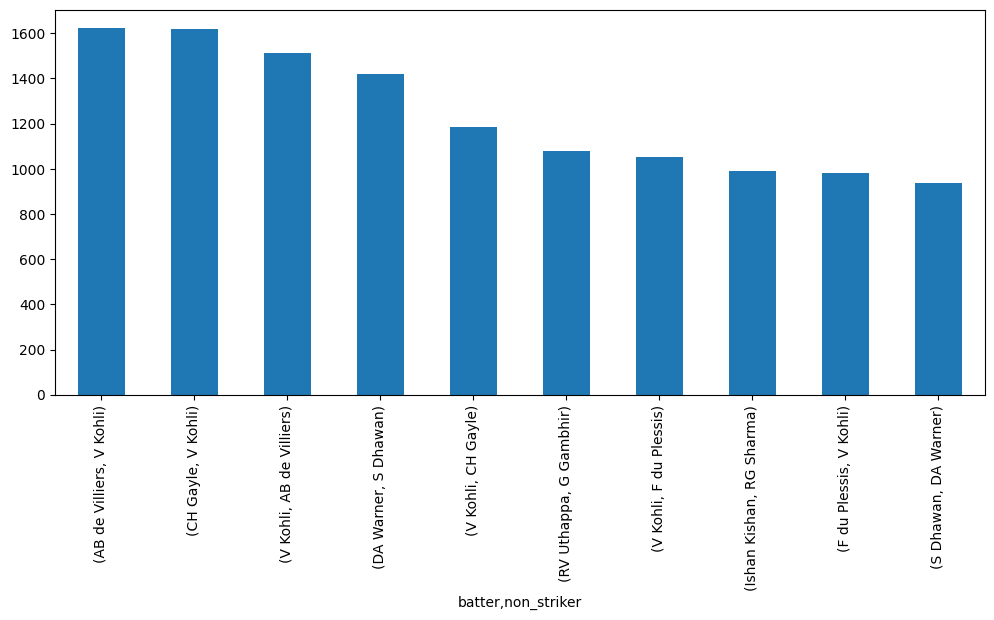

In [73]:
partnerships.plot(kind='bar', figsize=(12,5))

 Top Batting Partnerships


In [74]:
runs_by_over = (
    df.groupby('over')['total_runs']
      .sum()
)

runs_by_over

over
0     13651
1     16163
2     17895
3     18415
4     18565
5     18528
6     14839
7     15981
8     16639
9     16353
10    16779
11    17076
12    17205
13    17634
14    18149
15    18472
16    19012
17    19559
18    19076
19    17765
Name: total_runs, dtype: int64

<Axes: xlabel='over'>

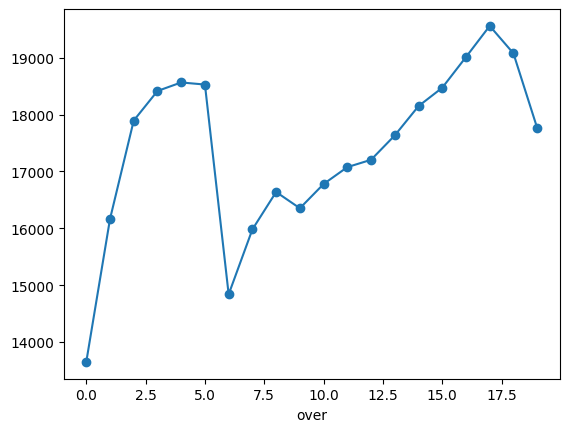

In [75]:
runs_by_over.plot(kind='line', marker='o')

Runs by Over Analysis

# Key Insights

- Virat Kohli emerged as the highest run scorer.
- Top wicket taking bowlers were identified.
- Teamwise run analysis highlighted dominant batting teams.
- Strike rate analysis revealed the most aggressive batters.
- Economy analysis identified the most economical bowlers.
- Batting partnership analysis showed successful batting combinations.
- Death overs contributed significantly to total scoring.